In [1]:
# 5-12 라이브러리 호출
import os
import time
import copy
import glob
import cv2 #openCV 라이브러리(오픈 소스 컴퓨터 비전 라이브러리)
import shutil

import numpy as np
import torch
import torchvision #컴퓨터 비전(computer vision)용도의 패키지
import torchvision.transforms as transforms #데이터 전처리를 위해 사용되는 패키지
import torchvision.models as models #다양한 파이토치 네트워크를 사용할 수 있도록 도와주는 패키지
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.models import ResNet18_Weights

import matplotlib.pyplot as plt

In [2]:
#5-13 이미지 데이터 전처리 방법 정의
data_path = './data/catanddog/train' # 이미지 데이터가 위치한 경로 지정

transform = transforms.Compose(
    [
        transforms.Resize([256, 256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
) #1

train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform = transform
) #2

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
) #3

print(len(train_dataset))

# 1. torchvision.transform : 이미지 데이터를 변환하여 모델(네트워크)의 입력으로 사용할 수 있게 변환
# 1-1. 파라미터
# transforms.Resize([256, 256]) -> Resize : 이미지 크기를 조정 256x256 크기로 조정 (합성곱층을 통과하기 위해 이미지 크기를 조정하는 전처리 과정)
# transforms.RandomResizedCrop(224) : 이미지를 랜덤한 크기 및 비율로 자름 (데이터 확장 용도로 사용, 이미지를 랜덤한 비율로 자른 후 데이터 크기 조정)
# transforms.RandomHoriziontalFlip() : 이미지를 랜덤하게 수평으로 뒤집음
# transforms.ToTensor() : 이미지 데이터를 텐서로 변환

# 2. datasets.ImageFolder : 데이터로더가 데이터를 불러올 대신(혹은 경로)과 방법(transform) or 전처리를 정의
# 2-1 파라미터
# data_path : 불러올 데이터가 위치한 경로
# transform : 이미지 데이터에 대한 전처리

# 3. 데이타로더 : 데이터를 불러오는 부분으로 앞에서 정의한 ImageFolder(train_dataset)을 데이터로더에 할당
# 한 번에 불러올 데이터양을 결정하는 batch_size 지정 -> 데이터를 무작위로 섞을(shuffle) 것인지 설정
# 3-1 파라미터
# train_dataset <- 데이터셋을 지정
# batch_size : 한 번에 불러올 데이터양을 결정하는 배치 크기 설정
# num_workers=8 -> num_workers : 데이터를 불러올 때 하위 프로세스를 몇 개 사용할지 설정, 너무 많은 하위 프로세스를 설정하게 되면 오류가 발생 or 메모리 부족 현상
# shuffle : 데이터를 무작위로 섞을지 지정 (True : 무작위 O)

385


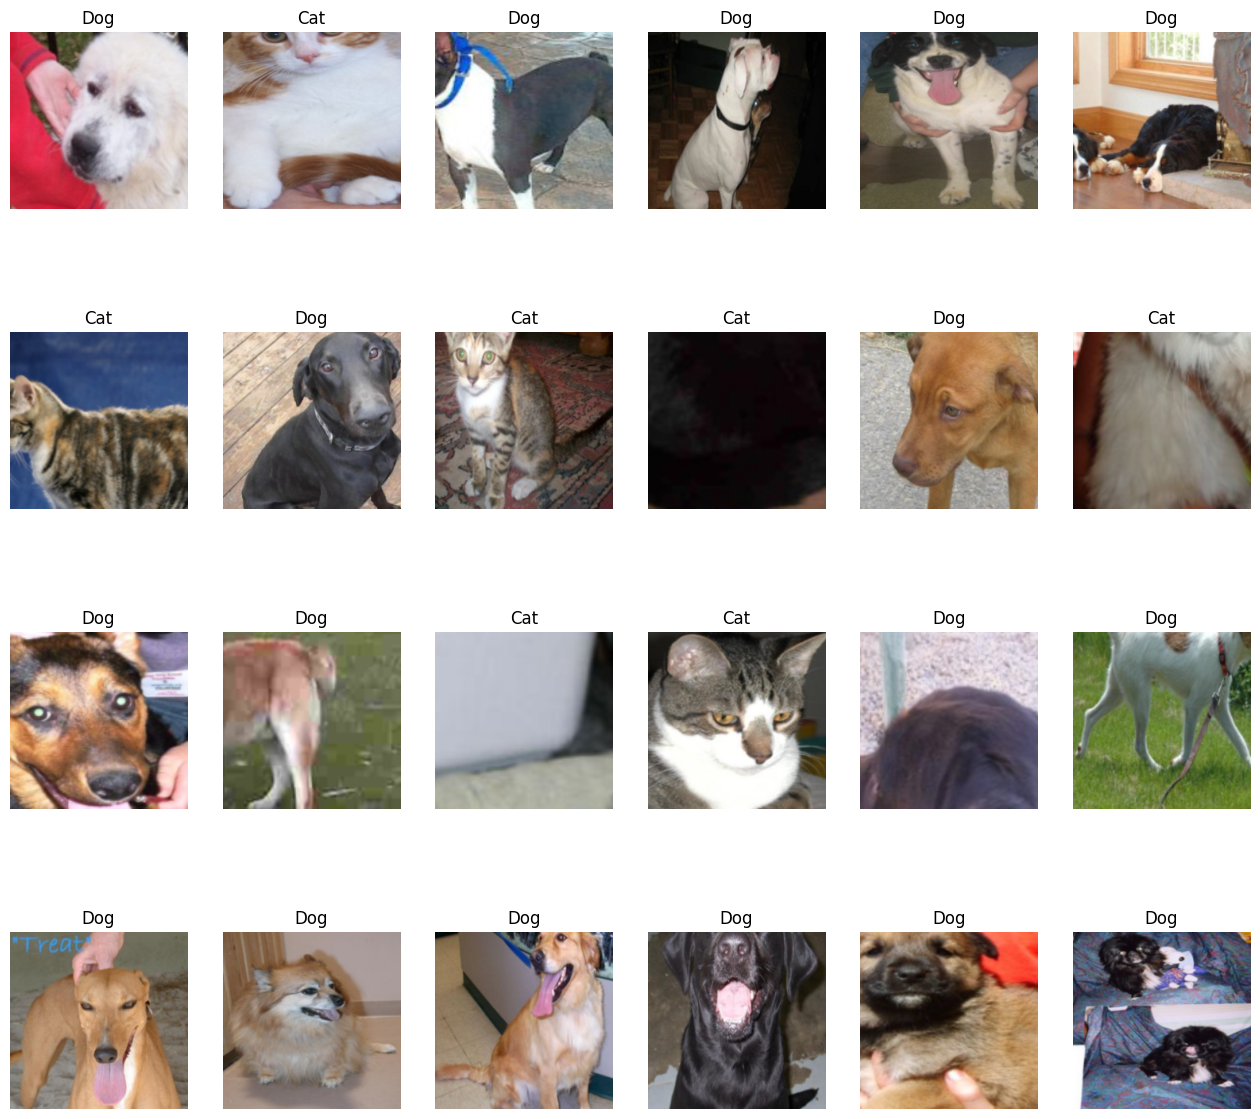

In [3]:
#5-14 학습에 사용될 이미지 출력
samples, labels = next(iter(train_loader)) #1
classes = { 0 : 'Cat', 1 : 'Dog'} #개오 고양이에 대한 클래스 구성

fig = plt.figure(figsize=(16, 24))

for i in range(24): #24개의 이미지 데이터 출력
    a = fig.add_subplot(4, 6, i+1)
    a.set_title(classes[labels[i].item()]) # 레이블 정보(클래스)를 함께 출력
    a.axis('off')
    a.imshow(np.transpose(samples[i].numpy(), (1, 2, 0))) #2
    plt.subplots_adjust(bottom=0.2, top=0.7, hspace=0)

# 1. 반복자(iterator, for 구문과 같은 효과)를 사용하려면 iter(), next()가 필요 
# iter() : 전달된 데이터 반복자를 꺼내 반환 -> next() 그 반복자가 다음에 출력해야할 요소로 반환
# 즉, iter()로 반복자를 구하고 그 반복자를 next()에 전달하여 차례대로 꺼냄
# 앞의 코드에서 반복자는 train_loader가 되며, train_loader에서 samples와 labels 값을 순차적으로 꺼내서 저장 

# 2. np.traspose() : 행과 열을 바꿈으로써 행렬의 차원을 바꿈 
# 행렬의 차원을 변경하는 이유 : 행렬의 내적 연산 -> 행과 열의 수가 달라 내적이 불가능할 때엔 transpse()나 reshape() 등으로 차원을 조정해야 함.
# 두번째 파라미터 (1, 2, 0) : 원본 자리의 기반으로 어떻게 배치할지 

In [4]:
# 5-15 사전에 훈련된 모델(ResNet18) 내려받기
#resnet18 = models.resnet18(pertrained=True) #pretraines=True는 사전에 학습된 가중치를 사용하겠다는 의미

resnet18 = models.resnet18(weights=ResNet18_Weights.DEFAULT)  # ImageNet으로 사전학습된 가중치 사용

# ResNet18 : 50개의 계층으로 구성된 합성곱 신경망
# ImageNet 데이터베이스의 100만 개가 넘는 영상을 이용하여 훈련된 신경망으로 전이 학습에 사용되도록 사전 훈련된 모델을 제공

In [5]:
# 5-16 사전에 훈련된 모델의 파라미터 학습 유무 지정
def set_parameter_requires_grad(model, feature_extracting=True):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False #1

set_parameter_requires_grad(resnet18)

# 1. 역전피 중 파라미터들에 대한 변화를 계산할 필요가 없다는 의미  *이 시점의 모든 파라미터를 얼림 (기존 fc 포함)
# 모델의 일부를 고정하고 나머지를 학습하고자 할 때 requires_grad = False로 설정 -> 이때 모델의 일부는 합성곱층(convolutional layer)과 풀림(pooling)층을 의미
# feature_extracting=True: 특성 추출 방식으로 쓸 것인가
# param.requires_grad = False: 이 파라미터에 대해 기울기(gradient)를 계산하지 말라는 뜻
# 기울기가 없으면 옵티마이저가 값을 업데이트할 수 없으므로 결과적으로 가중치가 고정


In [6]:
# 5-17 ResNet18에 완전연결층 추가 *기존 fc를 버리고 새 fc(Fully Connected layer(완전연결층)의 줄임말)로 교체
resnet18.fc = nn.Linear(512, 2) #2는 클래스가 두개라는 의미

In [7]:
# 5-18 모델의 파라미터 값 확인
for name, param in resnet18.named_parameters(): # model.named_parameters() : 모델에 접근하여 파라미터를 가져올 때 사용
    if param.requires_grad : 
        print(name, param.data) #학습 대상만 나옴

fc.weight tensor([[ 0.0379,  0.0115,  0.0071,  ...,  0.0149, -0.0210, -0.0239],
        [-0.0340,  0.0411, -0.0221,  ...,  0.0184, -0.0378, -0.0071]])
fc.bias tensor([0.0348, 0.0064])


In [8]:
# 5-19 모델 객체 생성 및 손실 함수 정의
model = models.resnet18(weights=ResNet18_Weights.DEFAULT) #모델의 객체 생성

for param in model.parameters(): #모델의 합성곱층 가중치 고정
    param.requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters(): #완전연결층은 학습
    param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss() #손실 함수 정의
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
# 5-20 모델 학습을 위한 함수 생성
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
    since = time.time() #컴퓨터의 현재 시각을 구하는 함수
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs): #에포크(13)만큼 반복
        print('Epoch {}/{}'.format(epoch, num_epochs-1))
        print('-' * 10)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders: #데이터로더에 전달된 데이터만큼 반복
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            model.to(device)
            optimizer.zero_grad() #기울기 0으로 설정
            outputs = model(inputs) #순전파 학습
            loss = criterion(outputs, labels) #오차 계산
            _, preds = torch.max(outputs, 1)
            loss.backward() #역전파 학습
            optimizer.step() #기울기 조정
    
            running_loss += loss.item() * inputs.size(0) # 출력 결과와 레이블 오차를 계산한 결과를 누적하여 저장
            running_corrects += torch.sum(preds == labels.data) # 출력 결과와 레이블이 동일한지 확인 후 결과를 누적하여 저장

        epoch_loss =running_loss / len(dataloaders.dataset) #평균오차 계산
        epoch_acc = running_corrects / len(dataloaders.dataset) #평균 전확도 계산

        print('Loss: {:.4f} Acc : {:.4f}'.format(epoch_loss, epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)
        torch.save(model.state_dict(), os.path.join('./data/catanddog/', '{0:0=2d}.pth'.format(epoch))) #모델 재 사용을 위해 저장

    time_elapsed = time.time() - since #실행 시간(학습 시간)을 계산
    print('Training complete in {:.0f}m {:0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc : {:4f}'.format(best_acc))
    return acc_history, loss_history

In [10]:
# 5-21 파라미터 학습 결과를 옵티마이저에 전달
params_to_update = []

for name, param in resnet18.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param) #파라미터 학습 결과 저장
        print("\t", name)

optimizer = optim.Adam(params_to_update) # 학습 결과를 옵티마이저에 전달

	 fc.weight
	 fc.bias


In [11]:
# 5-22 모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss() #손실 함수 지정
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------
Loss: 0.5696 Acc : 0.6805
Epoch 1/12
----------
Loss: 0.3708 Acc : 0.8260
Epoch 2/12
----------
Loss: 0.3124 Acc : 0.8727
Epoch 3/12
----------
Loss: 0.3099 Acc : 0.8364
Epoch 4/12
----------
Loss: 0.2773 Acc : 0.8909
Epoch 5/12
----------
Loss: 0.2108 Acc : 0.9351
Epoch 6/12
----------
Loss: 0.2702 Acc : 0.8961
Epoch 7/12
----------
Loss: 0.2300 Acc : 0.9039
Epoch 8/12
----------
Loss: 0.2355 Acc : 0.9117
Epoch 9/12
----------
Loss: 0.2628 Acc : 0.8909
Epoch 10/12
----------
Loss: 0.1978 Acc : 0.9221
Epoch 11/12
----------
Loss: 0.2364 Acc : 0.9039
Epoch 12/12
----------
Loss: 0.2047 Acc : 0.9247
Training complete in 10m 54.156803s
Best Acc : 0.935065


In [12]:
# 5-23 테스트 데이터 호출 및 전처리
test_path = './data/catanddog/test'

transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ]
)

test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


In [31]:
# 5-24 테스트 데이터 평가 함수 생성
def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob('./data/catanddog/' + '*.pth') #1
    saved_models.sort() # 불러온 .pth 파일들을 정렬
    print('saved_model', saved_models)
    print('------')

    for model_path in saved_models:
        print('Loading model', model_path)
        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)
        running_corrects = 0

        for inputs, labels in dataloaders: # 테스트 반복
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.no_grad(): #autograd를 사용하지 않겠다는 의미
                outputs = model(inputs) #데이터를 모델에 적용한 결과를 outputs에 저장

            _, preds = torch.max(outputs.data, 1) #2
            preds[preds >= 0.5] = 1 # torch.max로 출력된 값이 0.5보다 크면 올바르게 예측
            preds[preds < 0.5] = 0 # torch.max로 출력된 값이 0.5보다 작으면 틀리게 예측

            running_corrects += preds.eq(labels.cpu()).int().sum() #3

        epoch_acc = running_corrects.double() / len(dataloaders.dataset) #테스트 데이터의 정확도 계산
        print('Acc: {:4f}'.format(epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc
            
        acc_history.append(epoch_acc.item())
       

        time_elapsed = time.time() - since

    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    print('Best Acc : {:4f}'.format(best_acc))

    return acc_history #계산된 정확도 반환


# 1. glob : 현재 디렉터리에서 원하는 파일만 추출하여 가져올 때 사용 * 확장자 .pth을 가진 파일만 가져옴 -> pth : 훈련 데이터로 모델을 훈련시킬때 생성된 파일

# 2. torch.max : 주어진 텐서 배열의 최댓값이 들어있는 index를 반환
# ex y_pred = [[0.2, 0.7, 0.8, 0.4]]라는 배열에 torch.max(y_pred.data, 1)을 적용하면 최댓값은 0.8이며 인덱스 2를 반환함

#3. preds.eq(labels) : preds 배열과 labels가 일치하는지 검사하는 용도로 사용 
# 뒤에 사용된 sum()은 모델의 예측 결과와 정답(레이블)이 일치하는 것들의개수 합을 숫자로 출력 

In [32]:
# 5-25 테스트 데이터를 평가 함수에 적용
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['./data/catanddog/00.pth', './data/catanddog/01.pth', './data/catanddog/02.pth', './data/catanddog/03.pth', './data/catanddog/04.pth', './data/catanddog/05.pth', './data/catanddog/06.pth', './data/catanddog/07.pth', './data/catanddog/08.pth', './data/catanddog/09.pth', './data/catanddog/10.pth', './data/catanddog/11.pth', './data/catanddog/12.pth']
------
Loading model ./data/catanddog/00.pth
Acc: 0.877551
Loading model ./data/catanddog/01.pth
Acc: 0.928571
Loading model ./data/catanddog/02.pth
Acc: 0.887755
Loading model ./data/catanddog/03.pth
Acc: 0.969388
Loading model ./data/catanddog/04.pth
Acc: 0.908163
Loading model ./data/catanddog/05.pth
Acc: 0.918367
Loading model ./data/catanddog/06.pth
Acc: 0.928571
Loading model ./data/catanddog/07.pth
Acc: 0.918367
Loading model ./data/catanddog/08.pth
Acc: 0.938776
Loading model ./data/catanddog/09.pth
Acc: 0.938776
Loading model ./data/catanddog/10.pth
Acc: 0.938776
Loading model ./data/catanddog/11.pth
Acc: 0.938776
Loadi

13


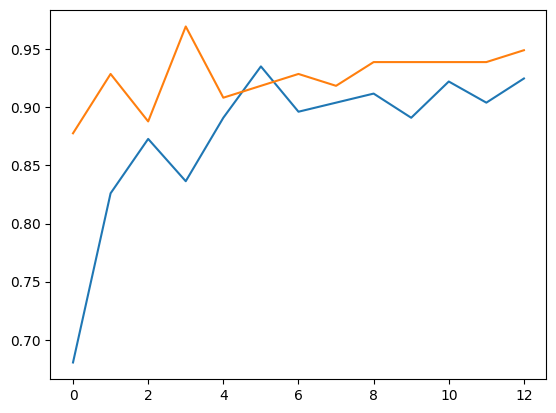

In [33]:
# 5-26 훈련과 테스트 데이터의 정확도를 그래프로 확인
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

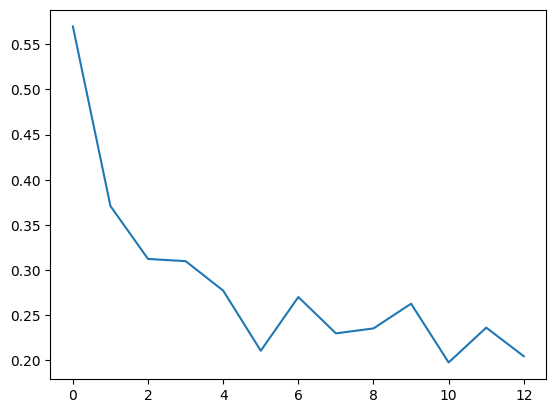

In [34]:
# 5-27 훈련 데이터의 오차에 대한 그래프 확인
plt.plot(train_loss_hist)
plt.show()

In [35]:
# 5-28 예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor):
    image = tensor.clone().detach().numpy() #1
    image = image.transpose(1, 2, 0)
    image = image * (np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)))
    image = image.clip(0, 1) #2
    return image

# 1 tensor.clone() : 기존 텐서의 내용을 복사한 텐서를 생성
# detach() : 기존 텐서에서 기울기가 전파되지 않는 텐서 
# => tensor.clone().detach() : 기존 텐서를 복사한 새로운 텐서를 생성하지만 기울기에 영향을 주지 않는다는 의미
# *PyTorch 텐서를 matplotlib가 그릴 수 있는 NumPy 배열로 바꾸는 작업인데, 원본에 영향을 주지 않기 위해 clone()
# pytorch 텐서는 계산 그래프를 가지고 나오는데 이미지 출력에는 필요없으므로 detach()


# 2 clip() : 입력 값이 주어진 범위를 벗어날 때 입력 값을 특정 범위로 제한시키기 위해 사용
# -> image.clip(0, 1) : image 데이터를 0과 1 사이의 값으로 제한하겠다는 의미
# ex. exam = np.array([-1.8, -1.2, -0.7, 0.0, 0.8, 1.4, 1.9])
# np.clip(exam, -0.5, 0.5) = [-0.5, -0.5, -0.5, 0, 0.5, 0.5, 0.5]

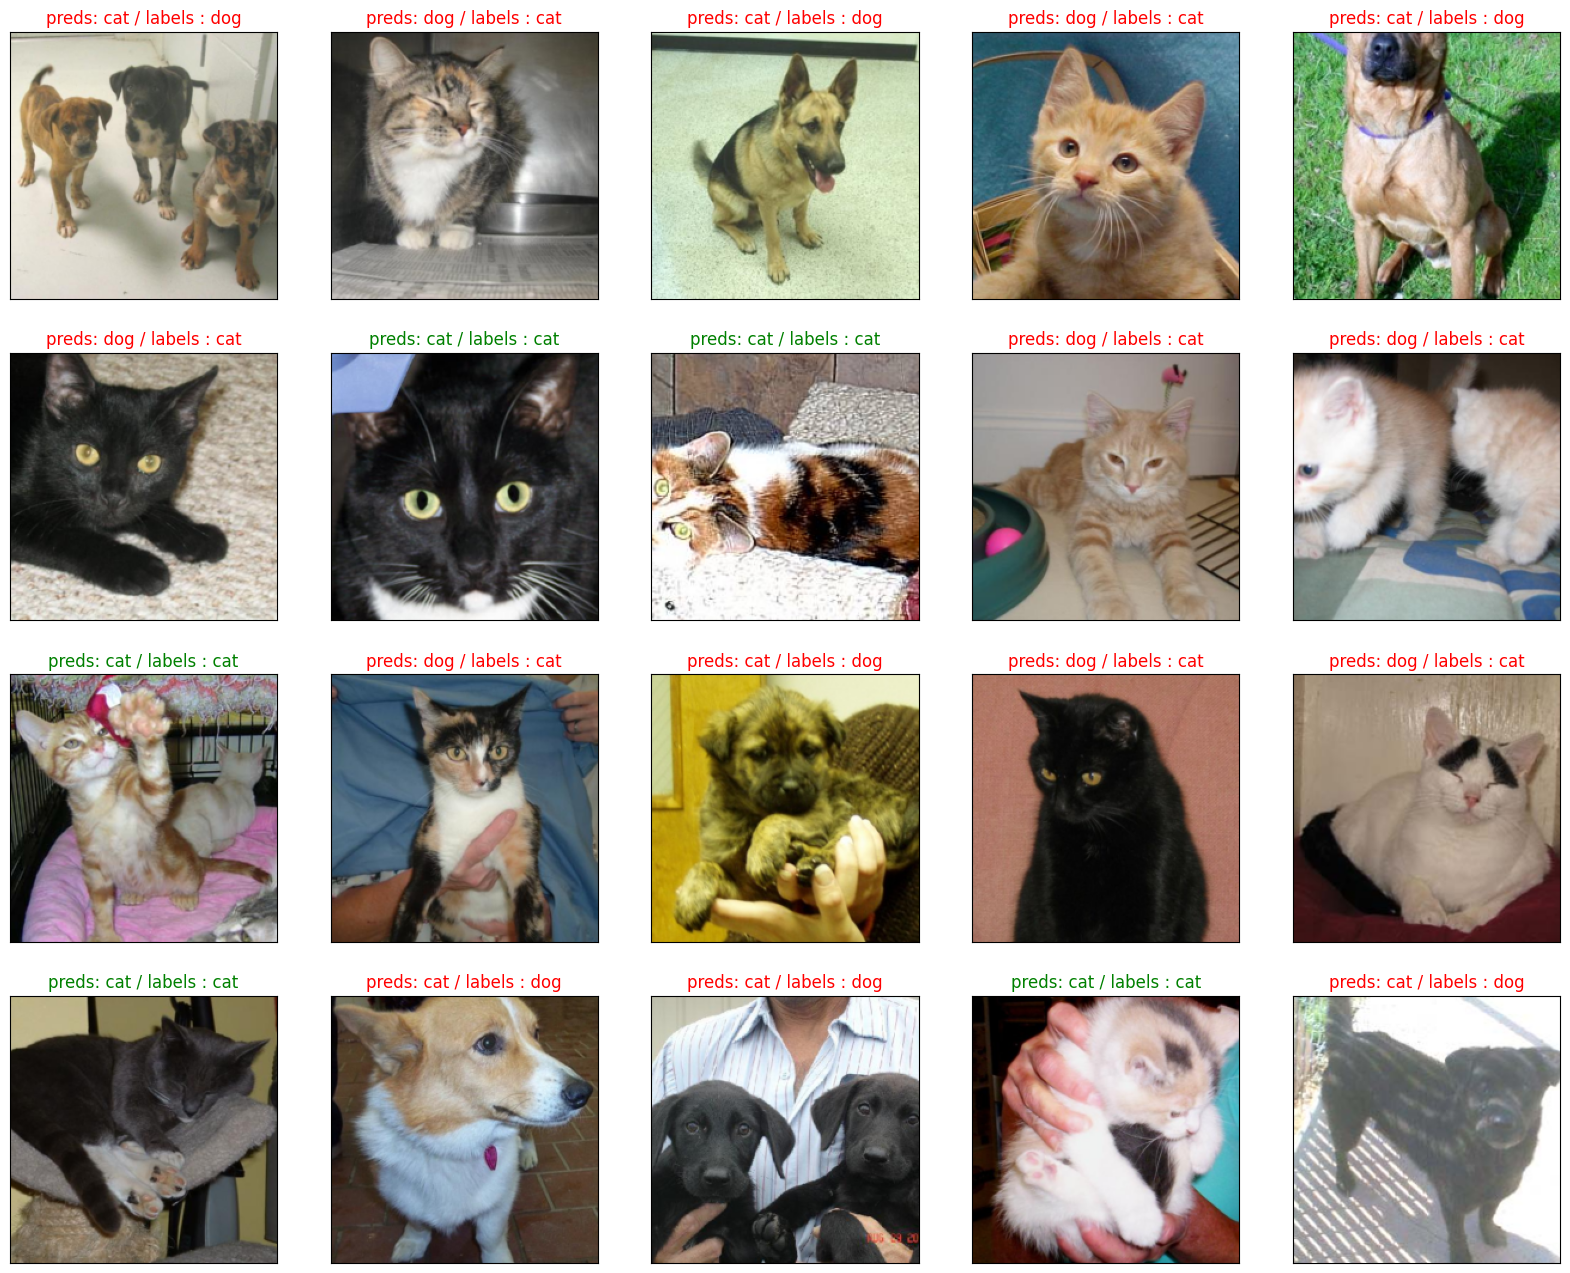

<Figure size 640x480 with 0 Axes>

In [56]:
# 5-29 개와 고양이 예측 결과 출력
classes = {0:'cat', 1 :'dog'} #개와 고양이 두개에 대한 레이블

dataiter = iter(test_loader) #테스트 데이터셋을 가져옴
images, labels = next(dataiter) #테스트 데이터셋에서 이미지와 레이블을 분리하여 가져옴
output = model(images)

_, preds = torch.max(output, 1) 

fig = plt.figure(figsize=(20, 16))

for idx in np.arange(20):
    
    ax = fig.add_subplot(4, 5, idx+1, xticks=[], yticks=[]) #1
    plt.imshow(im_convert(images[idx])) #이미지 출력을 위해 함수 적용

    a.set_title(classes[labels[i].item()])
    ax.set_title("preds: {} / labels : {}".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])),
    color=('green' if preds[idx] == labels[idx] else 'red')) #2

plt.show()
plt.subplots_adjust(bottom=0.1, top=0.4, hspace=0, wspace=0) #3


# 1 add_subplot(2, 10, idx+1, xticks=[], yticks=[]) : 한 화면에 여러 개의 이미지를 담기 위해 사용
# 첫번째 파라미터(ex. 2) : 행의 수를 의미 (이미지를 두줄로 출력)
# 두번째 파라미터(ex. 10) : 열의 수를 의미 (한 줄에 10개의 이미지를 출력)
# 세번째 파라미터(ex. idx+1) : 인덱스를 의미 (행과 열을 기준으로 순차적으로 이미지 출력)
# 네번째 파라미터(ex. xticks=[], yticks=[]) : x축, y축 틱(tick) 축 텍스트를 삭제 

# 2 classes[preds[idx].item()] : preds[idx].item() 값이 classes 로 정의된 '0'과 '1' 중 어떤 값을 갖는지 판별 (0이면 cat, 1이면 dog)

# 3 Figure 안에 서브플롯(subplot)의 위치를 조정할 때 사용 
# left, bottom, right, top으로 이미지 위치 조정, hspace, wspace로 서브플롯 간의 간격(너비와 높이의 비율)을 조정 